### Tutorial 14 : Batch Gradient Descent, Stochastic Gradient Descent and Mini Batch Gradient Descent

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv('tutorial14_homeprices_banglore.csv')
df

,area,bedrooms,price
0,1056,2,39.07
1,2600,4,120.00
2,1440,3,62.00
3,1521,3,75.00
4,1200,2,51.00
5,1170,2,38.00
6,2732,4,135.00
7,3300,4,155.00
8,1310,3,50.00
9,3700,5,167.00


In [3]:
df.sample(5)

,area,bedrooms,price
10,1800,3,82.0
1,2600,4,120.0
12,1000,2,38.0
16,1180,3,48.0
11,2785,4,140.0


In [4]:
from sklearn import preprocessing
sx = preprocessing.MinMaxScaler()
sy = preprocessing.MinMaxScaler()

In [5]:
scalled_X = sx.fit_transform(df.drop('price', axis='columns'))
scalled_X

array([[0.08827586, 0.25      ],
       [0.62068966, 0.75      ],
       [0.22068966, 0.5       ],
       [0.24862069, 0.5       ],
       [0.13793103, 0.25      ],
       [0.12758621, 0.25      ],
       [0.6662069 , 0.75      ],
       [0.86206897, 0.75      ],
       [0.17586207, 0.5       ],
       [1.        , 1.        ],
       [0.34482759, 0.5       ],
       [0.68448276, 0.75      ],
       [0.06896552, 0.25      ],
       [0.10344828, 0.25      ],
       [0.5       , 0.5       ],
       [0.12931034, 0.25      ],
       [0.13103448, 0.5       ],
       [0.25517241, 0.5       ],
       [0.67931034, 0.5       ],
       [0.        , 0.        ]])

In [8]:
scalled_Y = sy.fit_transform(df['price'].values.reshape(df.shape[0], 1))
scalled_Y

array([[0.05237037],
       [0.65185185],
       [0.22222222],
       [0.31851852],
       [0.14074074],
       [0.04444444],
       [0.76296296],
       [0.91111111],
       [0.13333333],
       [1.        ],
       [0.37037037],
       [0.8       ],
       [0.04444444],
       [0.05925926],
       [0.51111111],
       [0.07407407],
       [0.11851852],
       [0.20740741],
       [0.51851852],
       [0.        ]])

In [13]:
np.ones(shape=(1))

array([1.])

In [14]:
scalled_X

array([[0.08827586, 0.25      ],
       [0.62068966, 0.75      ],
       [0.22068966, 0.5       ],
       [0.24862069, 0.5       ],
       [0.13793103, 0.25      ],
       [0.12758621, 0.25      ],
       [0.6662069 , 0.75      ],
       [0.86206897, 0.75      ],
       [0.17586207, 0.5       ],
       [1.        , 1.        ],
       [0.34482759, 0.5       ],
       [0.68448276, 0.75      ],
       [0.06896552, 0.25      ],
       [0.10344828, 0.25      ],
       [0.5       , 0.5       ],
       [0.12931034, 0.25      ],
       [0.13103448, 0.5       ],
       [0.25517241, 0.5       ],
       [0.67931034, 0.5       ],
       [0.        , 0.        ]])

In [16]:
scalled_X.T

array([[0.08827586, 0.62068966, 0.22068966, 0.24862069, 0.13793103,
        0.12758621, 0.6662069 , 0.86206897, 0.17586207, 1.        ,
        0.34482759, 0.68448276, 0.06896552, 0.10344828, 0.5       ,
        0.12931034, 0.13103448, 0.25517241, 0.67931034, 0.        ],
       [0.25      , 0.75      , 0.5       , 0.5       , 0.25      ,
        0.25      , 0.75      , 0.75      , 0.5       , 1.        ,
        0.5       , 0.75      , 0.25      , 0.25      , 0.5       ,
        0.25      , 0.5       , 0.5       , 0.5       , 0.        ]])

In [18]:
w = np.ones(shape=(2))

In [19]:
np.dot(w, scalled_X.T)

array([0.33827586, 1.37068966, 0.72068966, 0.74862069, 0.38793103,
       0.37758621, 1.4162069 , 1.61206897, 0.67586207, 2.        ,
       0.84482759, 1.43448276, 0.31896552, 0.35344828, 1.        ,
       0.37931034, 0.63103448, 0.75517241, 1.17931034, 0.        ])

In [21]:
a = np.array([2, 4, 8])
b = np.array([3, 7, 4])
a - b

array([-1, -3,  4])

In [23]:
np.square(a - b)

array([ 1,  9, 16])

In [24]:
np.mean(np.square(a - b))

np.float64(8.666666666666666)

In [26]:
cost_list=[]
epoc_list=[]

In [28]:
def batch_gradient_descent(X, y_true, epochs, learning_rate = 0.01):
    number_of_features = X.shape[1]
    w = np.ones(shape=number_of_features)
    b = 0
    total_samples = X.shape[0]
    for i in range(epochs):
        y_predicted = np.dot(w, scalled_X.T) + b
        w_grad = - (2/total_samples)*(X.T.dot(y_true - y_predicted))
        b_grad = - (2/total_samples)*np.sum(y_true - y_predicted)
        w = w - learning_rate * w_grad
        b = b - learning_rate * b_grad
        cost = np.mean(np.square(y_true - y_predicted))
        if i % 10 == 0:
            cost_list.append(cost)
            epoc_list.append(i)
    return w, b, cost, cost_list, epoc_list
w, b, cost, cost_list, epoc_list = batch_gradient_descent(scalled_X, scalled_Y.reshape(scalled_Y.shape[0],), 500)
w, b, cost

(array([0.70712464, 0.67456527]),
 np.float64(-0.23034857438407427),
 np.float64(0.0068641890429808105))

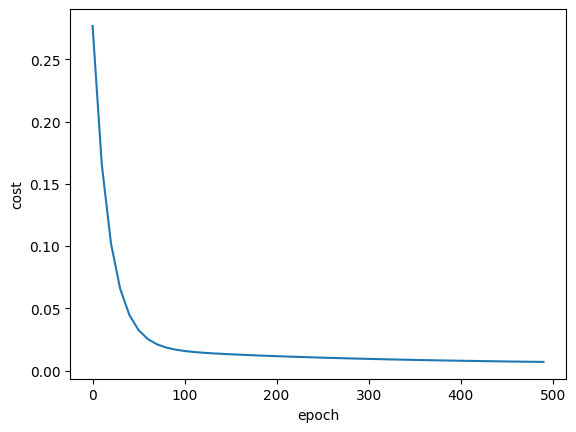

In [29]:
plt.xlabel('epoch')
plt.ylabel('cost')
plt.plot(epoc_list, cost_list)

In [30]:
w

array([0.70712464, 0.67456527])

In [33]:
sy.inverse_transform([[1, 0.5, 0]])
#transform means taking 0 to 1. inverse transform means again converting back to original value 0 has least value and 1 has max value

array([[167. ,  99.5,  32. ]])

In [38]:
def predict(area, bedroom, w, b):
    scaled_x = sx.transform([[area, bedroom]])[0]
    scaled_price = w[0] * scaled_x[0] + w[1] * scaled_x[1] + b
    return sy.inverse_transform([[scaled_price]])

In [39]:
predict(1000, 3, w, b)

C:\Users\Dell-Precession\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([[53.01967221]])

In [40]:
df

,area,bedrooms,price
0,1056,2,39.07
1,2600,4,120.00
2,1440,3,62.00
3,1521,3,75.00
4,1200,2,51.00
5,1170,2,38.00
6,2732,4,135.00
7,3300,4,155.00
8,1310,3,50.00
9,3700,5,167.00


In [41]:
predict(1000, 2, w, b)

C:\Users\Dell-Precession\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([[30.25309446]])

In [42]:
predict(1500, 3, w, b)

C:\Users\Dell-Precession\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([[69.47860786]])

In [43]:
predict(2700, 4, w, b)

C:\Users\Dell-Precession\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([[131.74663116]])

In [44]:
# the value is near the actual value

In [46]:
import random
random.randint(0,6)

4

In [67]:
def stochastic_gradient_descent(X, y_true, epochs, learning_rate = 0.01):
    number_of_features = X.shape[1]
    w = np.ones(shape=(number_of_features))
    b = 0
    total_samples = X.shape[0]
    cost_lists = []
    epoch_lists = []
    for i in range(epochs):
        random_index = random.randint(0, total_samples-1)
        sample_x = X[random_index]
        sample_y = y_true[random_index]
        y_predicted = np.dot(w, sample_x.T) + b
        w_grad = - (2/total_samples)*(sample_x.T.dot(sample_y - y_predicted))
        b_grad = - (2/total_samples)*np.sum(sample_y - y_predicted)
        w = w - learning_rate * w_grad
        b = b - learning_rate * b_grad
        cost = np.square(sample_y - y_predicted)
        if i % 100 == 0:
            cost_lists.append(cost)
            epoch_lists.append(i)
    return w, b, cost, cost_lists, epoch_lists
w_sgd, b_sgd, cost_sgd, cost_list_sgd, epoc_list_sgd = stochastic_gradient_descent(scalled_X, scalled_Y.reshape(scalled_Y.shape[0],), 10000) # Here we can give more epoch. Still this computation will be less. because this takes one by one randomly
w_sgd, b_sgd, cost_sgd

(array([0.70641862, 0.67245892]),
 np.float64(-0.22575435230109833),
 np.float64(0.001954487036965091))

In [68]:
w, b, cost

(array([0.70712464, 0.67456527]),
 np.float64(-0.23034857438407427),
 np.float64(0.0068641890429808105))

###### Both above are near

In [69]:
len(epoc_list_sgd)

100

In [70]:
len(cost_list_sgd)

100

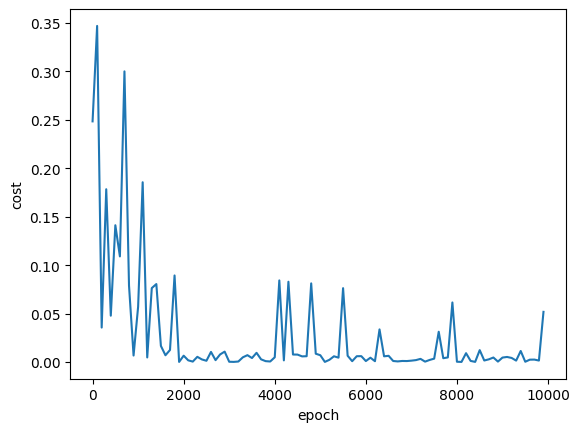

In [71]:
plt.xlabel('epoch')
plt.ylabel('cost')
plt.plot(epoc_list_sgd, cost_list_sgd)

###### Here we can find little zigzag line. But still reducing and comes to close at end

In [72]:
predict(1000, 2, w_sgd, b_sgd)

C:\Users\Dell-Precession\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([[30.79565185]])

In [73]:
predict(1500, 3, w_sgd, b_sgd)

C:\Users\Dell-Precession\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([[69.93364264]])

In [74]:
predict(2700, 4, w_sgd, b_sgd)

C:\Users\Dell-Precession\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([[132.09113668]])

###### Both gives nearly near values 